In [149]:
# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = "../saved_models/tutorial6"
import os
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# Tutorial 6: Transformers and Multi-Head Attention (Keras Version)

This notebook replicates the original PyTorch Lightning implementation using Keras and TensorFlow. All custom classes and logic are adapted for Keras.

In [150]:
# Standard libraries
import os
import numpy as np
import random
import math
import json
from functools import partial
import matplotlib.pyplot as plt
import seaborn as sns
sns.reset_orig()
from tqdm.notebook import tqdm

In [151]:
# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [152]:
# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

## The Transformer architecture (Keras)

In [153]:
def scaled_dot_product(q, k, v, mask=None):
    d_k = tf.cast(tf.shape(k)[-1], tf.float32)
    attn_logits = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(d_k)
    if mask is not None:
        attn_logits += (mask * -1e9)
    attention = tf.nn.softmax(attn_logits, axis=-1)
    values = tf.matmul(attention, v)
    return values, attention

In [154]:
seq_len, d_k = 3, 2
q = np.random.rand(seq_len, d_k).astype(np.float32)
k = np.random.rand(seq_len, d_k).astype(np.float32)
v = np.random.rand(seq_len, d_k).astype(np.float32)
values, attention = scaled_dot_product(q, k, v)
print("Q\n", q)
print("K\n", k)
print("V\n", v)
print("Values\n", values)
print("Attention\n", attention)

Q
 [[0.37454012 0.9507143 ]
 [0.7319939  0.5986585 ]
 [0.15601864 0.15599452]]
K
 [[0.05808361 0.8661761 ]
 [0.601115   0.7080726 ]
 [0.02058449 0.96990985]]
V
 [[0.83244264 0.21233912]
 [0.18182497 0.1834045 ]
 [0.30424225 0.52475643]]
Values
 tf.Tensor(
[[0.43363515 0.30964315]
 [0.41962066 0.2994583 ]
 [0.43551385 0.30560187]], shape=(3, 2), dtype=float32)
Attention
 tf.Tensor(
[[0.32259393 0.33493102 0.34247506]
 [0.3064095  0.3795805  0.31401005]
 [0.32779196 0.34201267 0.33019537]], shape=(3, 3), dtype=float32)


### Multi-Head Attention (Keras)

In [155]:
# Helper function to support different mask shapes.
# Output shape supports (batch_size, number of heads, seq length, seq length)
# If 2D: broadcasted over batch size and number of heads
# If 3D: broadcasted over number of heads
# If 4D: leave as is
def expand_mask(mask):
    assert mask.ndim >= 2, "Mask must be at least 2-dimensional with seq_length x seq_length"
    if mask.ndim == 3:
        mask = mask.unsqueeze(1)
    while mask.ndim < 4:
        mask = mask.unsqueeze(0)
    return mask

In [156]:
class MultiHeadAttention(layers.Layer):
    def __init__(self, input_dim, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0, "Embedding dimension must be divisible by number of heads."
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        # Keras Dense layers for QKV and output projections
        self.qkv_proj = layers.Dense(3 * embed_dim, use_bias=True,
                                     kernel_initializer=tf.keras.initializers.GlorotUniform())
        self.o_proj = layers.Dense(input_dim, use_bias=True,
                                  kernel_initializer=tf.keras.initializers.GlorotUniform())

    def call(self, x, mask=None, return_attention=False):
        batch_size = tf.shape(x)[0]
        seq_length = tf.shape(x)[1]
        # Project Q, K, V together
        qkv = self.qkv_proj(x)  # (batch_size, seq_length, 3*embed_dim)
        # Split Q, K, V
        qkv = tf.reshape(qkv, (batch_size, seq_length, self.num_heads, 3 * self.head_dim))
        qkv = tf.transpose(qkv, perm=[0, 2, 1, 3])  # (batch_size, num_heads, seq_length, 3*head_dim)
        q, k, v = tf.split(qkv, 3, axis=-1)  # Each: (batch_size, num_heads, seq_length, head_dim)
        # Use the helper for scaled dot-product attention
        values, attention = scaled_dot_product(q, k, v, mask=mask)
        # Rearrange and combine heads
        values = tf.transpose(values, perm=[0, 2, 1, 3])  # (batch_size, seq_length, num_heads, head_dim)
        values = tf.reshape(values, (batch_size, seq_length, self.embed_dim))
        # Output projection
        o = self.o_proj(values)
        if return_attention:
            return o, attention
        else:
            return o


### Transformer Encoder Block (Keras)

In [157]:
class EncoderBlock(layers.Layer):
    def __init__(self, input_dim, num_heads, dim_feedforward, dropout=0.0):
        super().__init__()
        self.attn = MultiHeadAttention(input_dim, input_dim, num_heads)
        self.ffn = keras.Sequential([
            layers.Dense(dim_feedforward),
            layers.Dropout(dropout),
            layers.Activation('relu'),
            layers.Dense(input_dim),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout = layers.Dropout(dropout)
    def call(self, x, mask=None):
        attn_out = self.attn(x, mask=mask)
        x = x + self.dropout(attn_out)
        x = self.norm1(x)
        ffn_out = self.ffn(x)
        x = x + self.dropout(ffn_out)
        x = self.norm2(x)
        return x


### Transformer Encoder (Keras)

In [158]:
class TransformerEncoder(layers.Layer):
    def __init__(self, num_layers, **block_args):
        super().__init__()
        self.layers = [EncoderBlock(**block_args) for _ in range(num_layers)]

    def call(self, x, mask=None):
        for l in self.layers:
            x = l(x, mask=mask)
        return x

    def get_attention_maps(self, x, mask=None):
        attention_maps = []
        for l in self.layers:
            # Get attention map from MultiHeadAttention in EncoderBlock
            _, attn_map = l.attn(x, mask=mask, return_attention=True)
            attention_maps.append(attn_map)
            x = l(x, mask=mask)
        return attention_maps


### Positional Encoding (Keras)

In [159]:
class PositionalEncoding(layers.Layer):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pos_encoding = np.zeros((max_len, d_model))
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.pos_encoding = tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        pos_encoding = self.pos_encoding[:seq_len]  # [seq_len, d_model]
        pos_encoding = tf.expand_dims(pos_encoding, axis=0)  # [1, seq_len, d_model]
        return x + pos_encoding


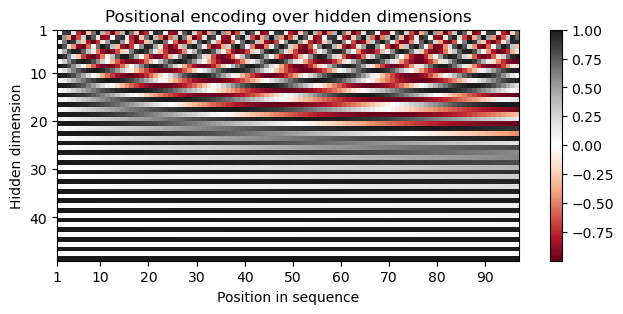

In [160]:
encod_block = PositionalEncoding(d_model=48, max_len=96)
pe = np.transpose(encod_block.pos_encoding)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,3))
pos = ax.imshow(pe, cmap="RdGy", extent=(1,pe.shape[1]+1,pe.shape[0]+1,1))
fig.colorbar(pos, ax=ax)
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Hidden dimension")
ax.set_title("Positional encoding over hidden dimensions")
ax.set_xticks([1]+[i*10 for i in range(1,1+pe.shape[1]//10)])
ax.set_yticks([1]+[i*10 for i in range(1,1+pe.shape[0]//10)])
plt.show()

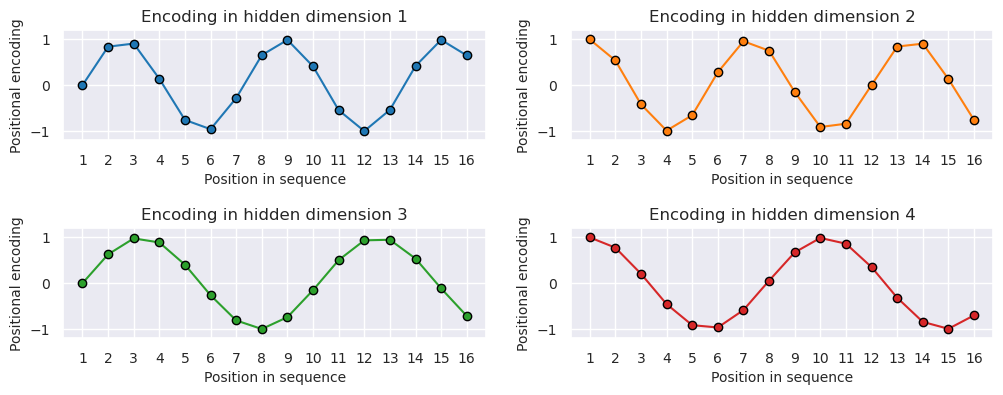

In [161]:
sns.set_theme()
fig, ax = plt.subplots(2, 2, figsize=(12,4))
ax = [a for a_list in ax for a in a_list]
for i in range(len(ax)):
    ax[i].plot(np.arange(1,17), pe[i,:16], color=f'C{i}', marker="o", markersize=6, markeredgecolor="black")
    ax[i].set_title(f"Encoding in hidden dimension {i+1}")
    ax[i].set_xlabel("Position in sequence", fontsize=10)
    ax[i].set_ylabel("Positional encoding", fontsize=10)
    ax[i].set_xticks(np.arange(1,17))
    ax[i].tick_params(axis='both', which='major', labelsize=10)
    ax[i].tick_params(axis='both', which='minor', labelsize=8)
    ax[i].set_ylim(-1.2, 1.2)
fig.subplots_adjust(hspace=0.8)
sns.reset_orig()
plt.show()

In [162]:
class CosineWarmupScheduler(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup, max_iters):
        super().__init__()
        self.base_lr = base_lr
        self.warmup = warmup
        self.max_iters = max_iters

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        lr_factor = 0.5 * (1 + tf.cos(np.pi * step / self.max_iters))
        warmup_factor = tf.where(step <= self.warmup, step / self.warmup, 1.0)
        lr_factor *= warmup_factor
        return self.base_lr * lr_factor

In [163]:
class TransformerPredictor(tf.keras.Model):
    def __init__(self, input_dim, model_dim, num_classes, num_heads, num_layers, lr, warmup, max_iters, dropout=0.0, input_dropout=0.0):
        super().__init__()
        # Input mapping: Dropout then Dense (matches PyTorch)
        self.input_net = keras.Sequential([
            layers.Dropout(input_dropout),
            layers.Dense(model_dim)
        ])
        self.positional_encoding = PositionalEncoding(d_model=model_dim)
        self.transformer = TransformerEncoder(
            num_layers=num_layers,
            input_dim=model_dim,
            dim_feedforward=2*model_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        # Output mapping: Dense, LayerNorm, ReLU, Dropout, Dense (matches PyTorch)
        self.output_net = keras.Sequential([
            layers.Dense(model_dim),
            layers.LayerNormalization(epsilon=1e-6),
            layers.Activation('relu'),
            layers.Dropout(dropout),
            layers.Dense(num_classes)
        ])
        self.lr_schedule = CosineWarmupScheduler(base_lr=lr, warmup=warmup, max_iters=max_iters)
        self.optimizer = keras.optimizers.Adam(learning_rate=self.lr_schedule)
    def call(self, x, mask=None, add_positional_encoding=True):
        x = self.input_net(x)
        if add_positional_encoding:
            x = self.positional_encoding(x)
        x = self.transformer(x, mask=mask)
        x = self.output_net(x)
        return x
    def get_attention_maps(self, x, mask=None, add_positional_encoding=True):
        x = self.input_net(x)
        if add_positional_encoding:
            x = self.positional_encoding(x)
        attention_maps = self.transformer.get_attention_maps(x, mask=mask)
        return attention_maps

## Reverse Sequence Dataset (Keras)

In [164]:
class ReverseDataset(tf.keras.utils.Sequence):
    def __init__(self, num_categories, seq_len, size, batch_size, shuffle=True):
        self.num_categories = num_categories
        self.seq_len = seq_len
        self.size = size
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.data = np.random.randint(num_categories, size=(size, seq_len))
        self.indices = np.arange(self.size)
        self.on_epoch_end()
    def __len__(self):
        return self.size // self.batch_size
    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_x = self.data[batch_indices]
        batch_y = np.flip(batch_x, axis=1)
        return batch_x, batch_y
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

## Build the Keras Transformer Model

In [165]:
def build_transformer(seq_length=16, vocab_size=10, d_model=32, num_heads=1, ff_dim=64, num_layers=1, dropout=0.0):
    inputs = layers.Input(shape=(seq_length,))
    x = layers.Embedding(vocab_size, d_model)(inputs)
    x = PositionalEncoding(d_model, max_len=seq_length)(x)
    x = TransformerEncoder(
        num_layers,
        input_dim=d_model,
        num_heads=num_heads,
        dim_feedforward=ff_dim,
        dropout=dropout
    )(x)
    x = layers.Dense(vocab_size, activation='softmax')(x)
    model = keras.Model(inputs, x)
    return model


## Prepare Data Loaders

In [166]:
train_dataset = ReverseDataset(10, 16, 50000, 128, shuffle=True)
val_dataset = ReverseDataset(10, 16, 1000, 128, shuffle=False)
test_dataset = ReverseDataset(10, 16, 10000, 128, shuffle=False)

In [167]:
train_dataset[0]

(array([[6, 9, 3, ..., 4, 7, 0],
        [8, 5, 1, ..., 2, 2, 5],
        [6, 2, 3, ..., 9, 0, 4],
        ...,
        [7, 3, 4, ..., 3, 7, 3],
        [6, 9, 1, ..., 0, 5, 9],
        [4, 7, 8, ..., 5, 5, 5]], shape=(128, 16), dtype=int32),
 array([[0, 7, 4, ..., 3, 9, 6],
        [5, 2, 2, ..., 1, 5, 8],
        [4, 0, 9, ..., 3, 2, 6],
        ...,
        [3, 7, 3, ..., 4, 3, 7],
        [9, 5, 0, ..., 1, 9, 6],
        [5, 5, 5, ..., 8, 7, 4]], shape=(128, 16), dtype=int32))

## Train the Model

In [168]:
class ReversePredictor(TransformerPredictor):
    def _calculate_loss(self, batch, mode="train"):
        inp_data, labels = batch
        inp_data = tf.one_hot(inp_data, depth=self.output_net.layers[-1].units, dtype=tf.float32)
        preds = self.call(inp_data, add_positional_encoding=True)
        preds_flat = tf.reshape(preds, [-1, preds.shape[-1]])
        labels_flat = tf.reshape(labels, [-1])
        loss = tf.keras.losses.sparse_categorical_crossentropy(labels_flat, preds_flat, from_logits=False)
        loss = tf.reduce_mean(loss)
        pred_labels = tf.cast(tf.argmax(preds, axis=-1), labels.dtype)
        acc = tf.reduce_mean(tf.cast(tf.equal(pred_labels, labels), tf.float32))
        if tf.executing_eagerly():
            print(f"{mode}_loss: {float(loss):.4f}")
            print(f"{mode}_acc: {float(acc):.4f}")
        return loss, acc
    def train_step(self, batch):
        # Step the learning rate scheduler manually per batch
        step = tf.cast(self.optimizer.iterations, tf.float32)
        if hasattr(self.optimizer, 'learning_rate') and hasattr(self.optimizer.learning_rate, '__call__'):
            lr = float(self.optimizer.learning_rate(step))
            tf.keras.backend.set_value(self.optimizer.lr, lr)
        loss, acc = self._calculate_loss(batch, mode="train")
        self.compiled_metrics.update_state(tf.cast(tf.argmax(self.call(tf.one_hot(batch[0], depth=self.output_net.layers[-1].units, dtype=tf.float32), add_positional_encoding=True), axis=-1), batch[1].dtype), batch[1])
        return {m.name: m.result() for m in self.metrics} | {"loss": loss}
    def test_step(self, batch):
        loss, acc = self._calculate_loss(batch, mode="test")
        self.compiled_metrics.update_state(tf.cast(tf.argmax(self.call(tf.one_hot(batch[0], depth=self.output_net.layers[-1].units, dtype=tf.float32), add_positional_encoding=True), axis=-1), batch[1].dtype), batch[1])
        return {m.name: m.result() for m in self.metrics} | {"loss": loss}
    def validation_step(self, batch):
        loss, acc = self._calculate_loss(batch, mode="val")
        self.compiled_metrics.update_state(tf.cast(tf.argmax(self.call(tf.one_hot(batch[0], depth=self.output_net.layers[-1].units, dtype=tf.float32), add_positional_encoding=True), axis=-1), batch[1].dtype), batch[1])
        return {m.name: m.result() for m in self.metrics} | {"loss": loss}

In [169]:
def train_reverse(**kwargs):
    # Use the learning rate from kwargs if provided, else default to 1e-3
    lr = kwargs.get('lr', 1e-3)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=5.0)
    model = ReversePredictor(**kwargs)
    # ModelCheckpoint callback to save best weights by validation accuracy (remove restore_best_weights)
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath='reverse_best_weights.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    )
    # Custom callback for batch-wise logging
    class BatchLogger(tf.keras.callbacks.Callback):
        def on_train_batch_end(self, batch, logs=None):
            print(f"Batch {batch+1}: loss={logs['loss']:.4f}, acc={logs['accuracy']:.4f}")
    # Compile your model
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    # Fit the model
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=10,
        callbacks=[checkpoint_cb, BatchLogger()]
    )
    # Restore best weights only if the file exists
    import os
    if os.path.exists('reverse_best_weights.h5'):
        model.load_weights('reverse_best_weights.h5')
    # Evaluate on validation and test sets using model.evaluate
    val_loss, val_acc = model.evaluate(val_dataset, verbose=0)
    test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
    result = {"test_acc": test_acc, "val_acc": val_acc}
    return model, result

In [170]:
def train_reverse(**kwargs):
    import tensorflow as tf
    import os
    model = ReversePredictor(**kwargs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=kwargs['lr'])
    # Build the model by calling it on a sample batch
    sample_x, _ = train_dataset[0]
    sample_x = tf.one_hot(sample_x, depth=model.output_net.layers[-1].units, dtype=tf.float32)
    model(sample_x)
    class BatchLogger(tf.keras.callbacks.Callback):
        def on_train_batch_end(self, batch, logs=None):
            print(f"Batch {batch+1}: loss={logs['loss']:.4f}, acc={logs['accuracy']:.4f}")
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath='reverse_best_weights.weights.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    )
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=10,
        callbacks=[checkpoint_cb, BatchLogger()]
    )
    # Restore best weights only if the file exists
    if os.path.exists('reverse_best_weights.weights.h5'):
        model.load_weights('reverse_best_weights.weights.h5')
    val_loss, val_acc = model.evaluate(val_dataset, verbose=0)
    test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
    result = {"test_acc": test_acc, "val_acc": val_acc}
    return model, result

reverse_model, reverse_result = train_reverse(input_dim=train_dataset.num_categories,
                                              model_dim=32,
                                              num_heads=1,
                                              num_classes=train_dataset.num_categories,
                                              num_layers=1,
                                              dropout=0.0,
                                              lr=5e-4,
                                              warmup=50,
                                              max_iters=len(train_dataset) * 10)

Epoch 1/10


C:\Users\sbrad\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
C:\Users\sbrad\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\tensorflow\trainer.py:670: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


Batch 1: loss=13.0876, acc=0.1719
  1/390 ━━━━━━━━━━━━━━━━━━━━ 6:12 957ms/step - accuracy: 0.1719 - loss: 13.0876Batch 2: loss=12.9533, acc=0.1250
Batch 3: loss=12.9031, acc=0.1146
Batch 4: loss=13.1681, acc=0.1152
Batch 5: loss=13.2294, acc=0.1234
Batch 6: loss=13.1975, acc=0.1185
Batch 7: loss=13.0731, acc=0.1239
Batch 8: loss=13.0386, acc=0.1182
  8/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1263 - loss: 13.0813    Batch 9: loss=13.2872, acc=0.1137
Batch 10: loss=13.1481, acc=0.1172
Batch 11: loss=13.1788, acc=0.1172
Batch 12: loss=12.8681, acc=0.1185
Batch 13: loss=13.0315, acc=0.1202
Batch 14: loss=13.0480, acc=0.1172
Batch 15: loss=12.8116, acc=0.1182
Batch 16: loss=13.0863, acc=0.1177
 16/390 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1219 - loss: 13.0694Batch 17: loss=12.8817, acc=0.1181
Batch 18: loss=13.1289, acc=0.1181
Batch 19: loss=13.2375, acc=0.1184
Batch 20: loss=13.2665, acc=0.1168
Batch 21: loss=12.9840, acc=0.1153
Batch 22: loss=13.1976, acc=0.1129
Batch 

C:\Users\sbrad\AppData\Roaming\Python\Python313\site-packages\keras\src\callbacks\model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


Batch 9: loss=12.7365, acc=0.1224
Batch 10: loss=13.1707, acc=0.1234
Batch 11: loss=13.0900, acc=0.1236
Batch 12: loss=12.9659, acc=0.1230
Batch 13: loss=13.2163, acc=0.1262
Batch 14: loss=13.1697, acc=0.1250
 14/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1251 - loss: 13.1373Batch 15: loss=12.9668, acc=0.1260
Batch 16: loss=12.8627, acc=0.1270
Batch 17: loss=13.0701, acc=0.1278
Batch 18: loss=13.0708, acc=0.1254
Batch 19: loss=12.9657, acc=0.1266
 19/390 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1255 - loss: 13.0978Batch 20: loss=12.9458, acc=0.1262
Batch 21: loss=13.0523, acc=0.1272
Batch 22: loss=12.8922, acc=0.1275
Batch 23: loss=13.1266, acc=0.1240
Batch 24: loss=13.1965, acc=0.1253
Batch 25: loss=13.0910, acc=0.1253
Batch 26: loss=13.0623, acc=0.1259
 26/390 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1256 - loss: 13.0856Batch 27: loss=13.0969, acc=0.1244
Batch 28: loss=13.0671, acc=0.1244
Batch 29: loss=13.1724, acc=0.1237
Batch 30: loss=12.9395, acc=0.1240
Batch 

In [175]:
val_acc = float(reverse_result['val_acc']['accuracy'].numpy())
test_acc = float(reverse_result['test_acc']['accuracy'].numpy())
print(f"Val accuracy:  {(100.0 * val_acc):4.2f}%")
print(f"Test accuracy: {(100.0 * test_acc):4.2f}%")

Val accuracy:  11.94%
Test accuracy: 12.11%


In [ ]:
# get the first sequence from the first batch of the training dataset
train_batch = train_dataset[0]
inp_data, labels = train_batch[0][0], train_batch[1][0]
print("Input data:", inp_data)
print("Labels:    ", labels)


Input data: [3 5 1 9 5 7 2 3 3 1 7 0 4 0 2 1]
Labels:     [1 2 0 4 0 7 1 3 3 2 7 5 9 1 5 3]


In [ ]:
# Save and load model weights in Keras, matching PyTorch Lightning style
reverse_checkpoint_path = os.path.join(CHECKPOINT_PATH, "ReverseTask.keras")
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(reverse_checkpoint_path, save_weights_only=True, monitor="val_accuracy", mode="max", save_best_only=True)

In [ ]:
# After training, restore best weights as in PyTorch Lightning
if os.path.exists(reverse_checkpoint_path):
    reverse_model.load_weights(reverse_checkpoint_path)